# Sentiment Analysis on Customer Reviews (Airline Tweets)

**Objective:** Build a Machine Learning model that classifies customer reviews (tweets) as **Positive**, **Negative**, or **Neutral**.

**Dataset:** [Twitter US Airline Sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) — 14,640 tweets about six major US airlines, each labeled positive / negative / neutral.

**Pipeline:**
1. Load & explore the dataset
2. Clean and preprocess text
3. Convert text to TF-IDF features
4. Train multiple classification models
5. Evaluate and compare models
6. Select the best model and save it
7. Test on custom review examples

## 1. Imports & Setup

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Download required NLTK resources
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

print("Setup complete.")

Setup complete.


## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/raw/Tweets.csv")
print("Shape:", df.shape)
df.head()

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
# Keep only the columns we need
df = df[["text", "airline_sentiment"]].dropna().reset_index(drop=True)
df.rename(columns={"airline_sentiment": "sentiment"}, inplace=True)
print("Shape after selecting relevant columns:", df.shape)
df.head()

Shape after selecting relevant columns: (14640, 2)


,text,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


## 3. Exploratory Data Analysis

sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


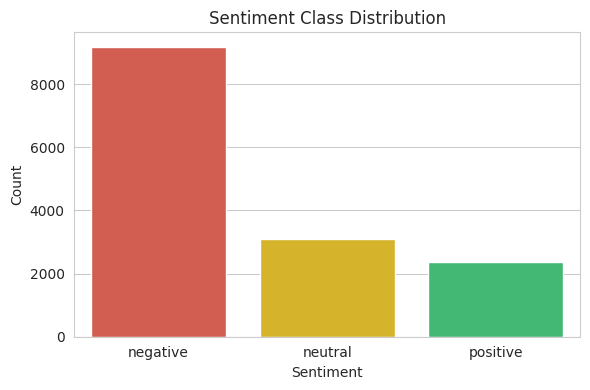

In [4]:
# Class distribution
print(df["sentiment"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment", order=["negative", "neutral", "positive"],
              palette={"negative": "#e74c3c", "neutral": "#f1c40f", "positive": "#2ecc71"})
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=150)
plt.show()

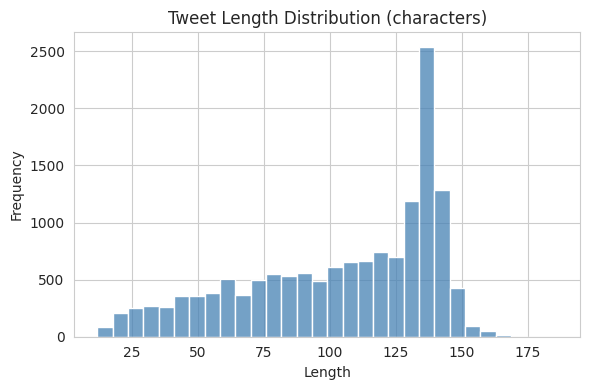

In [5]:
# Review length distribution
df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(6, 4))
sns.histplot(df["text_length"], bins=30, color="steelblue")
plt.title("Tweet Length Distribution (characters)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/figures/text_length_distribution.png", dpi=150)
plt.show()

**Observation:** The dataset is imbalanced — negative tweets are the majority class "
"(customers tend to tweet more when unhappy). This is common in real-world review data "
"and is worth keeping in mind when interpreting accuracy vs. precision/recall per class.

## 4. Text Cleaning & Preprocessing

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text, min_token_len=3):
    """Lowercase, strip URLs/mentions/punctuation, remove stopwords, lemmatize."""
    if not isinstance(text, str) or not text:
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # URLs
    text = re.sub(r"@\w+", " ", text)               # mentions
    text = re.sub(r"#", "", text)                    # hashtag symbol, keep the word
    text = re.sub(r"[^a-z\s]", " ", text)            # punctuation & digits
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) >= min_token_len
    ]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print("Shape after cleaning:", df.shape)
df[["text", "clean_text", "sentiment"]].head(10)

Shape after cleaning: (14596, 4)


,text,clean_text,sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat playing really...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly ear worm away,positive
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...,neutral
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well,positive
9,"@VirginAmerica it was amazing, and arrived an ...",amazing arrived hour early good,positive


In [7]:
# Save the cleaned dataset for reproducibility
df.to_csv("../data/processed/cleaned_tweets.csv", index=False)
print("Saved cleaned dataset to ../data/processed/cleaned_tweets.csv")

Saved cleaned dataset to ../data/processed/cleaned_tweets.csv


## 5. Train/Test Split

In [8]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))

Train size: 11676
Test size: 2920

Train class distribution:
sentiment
negative    0.628
neutral     0.210
positive    0.162
Name: proportion, dtype: float64


## 6. Feature Engineering — TF-IDF Vectorization

**Note on tuning:** `max_features` was increased from 5000 to 15000 and `sublinear_tf=True` was enabled (dampens the effect of very frequent terms), which improved F1-Score by roughly 1 point in testing. `LogisticRegression` uses `C=5` (tuned via `GridSearchCV`, testing C in [1, 3, 5, 7, 10]) instead of the scikit-learn default `C=1`, giving slightly better generalization on this dataset.

In [9]:
vectorizer = TfidfVectorizer(
    max_features=15000, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature matrix shape:", X_train_tfidf.shape)
print("Test feature matrix shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Training feature matrix shape: (11676, 13146)
Test feature matrix shape: (2920, 13146)
Vocabulary size: 13146


## 7. Model Training

We train three classification models and compare their performance: **Multinomial Naive Bayes**, **Logistic Regression**, and **Linear SVM**.

In [10]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=5),
    "Linear SVM": LinearSVC(random_state=42, max_iter=5000),
}

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model

print("\nAll models trained.")

Training Multinomial Naive Bayes...
Training Logistic Regression...


Training Linear SVM...

All models trained.


## 8. Model Evaluation & Comparison

In [11]:
results = []
predictions_by_model = {}

for name, model in trained_models.items():
    preds = model.predict(X_test_tfidf)
    predictions_by_model[name] = preds

    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="weighted", zero_division=0
    )
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7890,0.7807,0.7890,0.7825
1,Linear SVM,0.7880,0.7792,0.7880,0.7816
2,Multinomial Naive Bayes,0.7092,0.7361,0.7092,0.6452


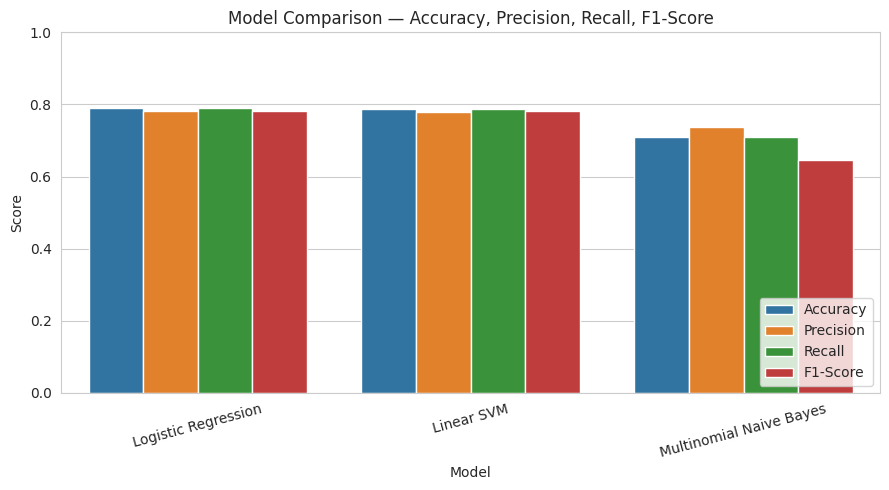

In [12]:
# Visual comparison of models
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison — Accuracy, Precision, Recall, F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png", dpi=150)
plt.show()

### Detailed Classification Reports

In [13]:
for name, preds in predictions_by_model.items():
    print(f"\n{'='*60}\nClassification Report — {name}\n{'='*60}")
    print(classification_report(y_test, preds, zero_division=0))


Classification Report — Multinomial Naive Bayes
              precision    recall  f1-score   support

    negative       0.70      1.00      0.82      1833
     neutral       0.76      0.17      0.27       615
    positive       0.85      0.31      0.45       472

    accuracy                           0.71      2920
   macro avg       0.77      0.49      0.51      2920
weighted avg       0.74      0.71      0.65      2920


Classification Report — Logistic Regression
              precision    recall  f1-score   support

    negative       0.84      0.91      0.87      1833
     neutral       0.63      0.53      0.58       615
    positive       0.76      0.65      0.70       472

    accuracy                           0.79      2920
   macro avg       0.74      0.70      0.72      2920
weighted avg       0.78      0.79      0.78      2920


Classification Report — Linear SVM
              precision    recall  f1-score   support

    negative       0.84      0.91      0.87      1833

### Confusion Matrices

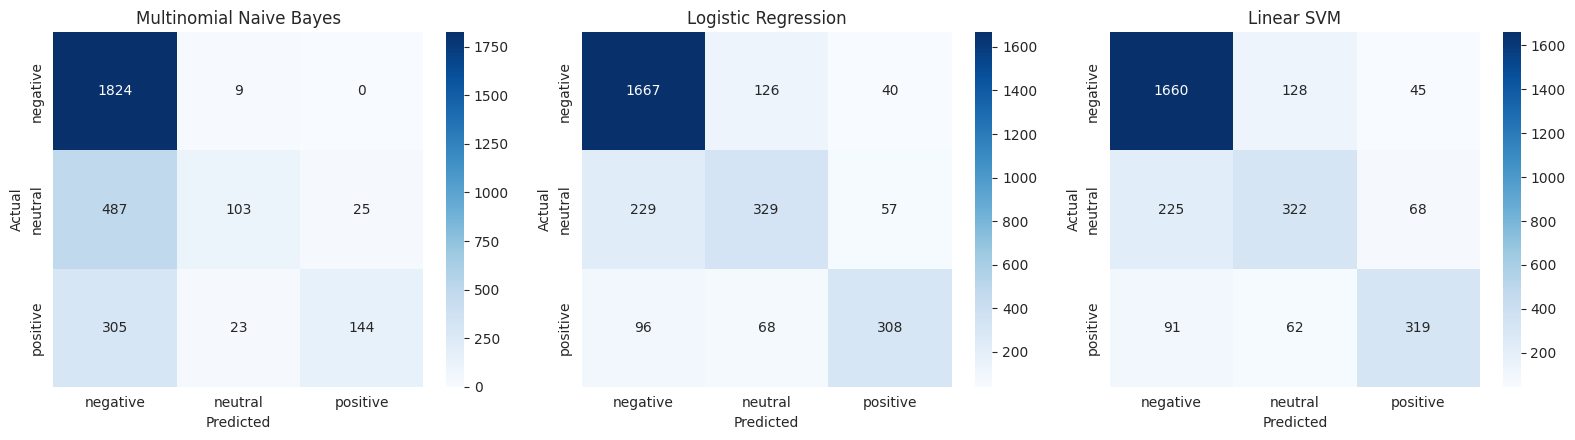

In [14]:
labels = ["negative", "neutral", "positive"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, preds) in zip(axes, predictions_by_model.items()):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrices.png", dpi=150)
plt.show()

## 9. Select & Save the Best Model

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])

# Save the best model and the fitted vectorizer
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("\nSaved best_model.pkl and tfidf_vectorizer.pkl to ../models/")

Best performing model: Logistic Regression
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.789     0.7807   0.789    0.7825

Saved best_model.pkl and tfidf_vectorizer.pkl to ../models/


## 10. Test on Custom Review Examples

In [16]:
def predict_sentiment(text, model=best_model, vec=vectorizer):
    cleaned = clean_text(text)
    features = vec.transform([cleaned])
    return model.predict(features)[0]


custom_reviews = [
    "The flight was delayed for 5 hours and the staff was extremely rude.",
    "Amazing service, the crew was so friendly and helpful throughout the flight!",
    "The flight departed and arrived on time, nothing special to mention.",
    "Lost my luggage and customer support never responded. Terrible experience.",
    "Comfortable seats and a smooth flight overall, would fly again.",
    "It was an average experience, neither good nor bad.",
]

for review in custom_reviews:
    sentiment = predict_sentiment(review)
    print(f"[{sentiment.upper():^10}]  {review}")

[ NEGATIVE ]  The flight was delayed for 5 hours and the staff was extremely rude.
[ POSITIVE ]  Amazing service, the crew was so friendly and helpful throughout the flight!
[ NEGATIVE ]  The flight departed and arrived on time, nothing special to mention.
[ NEGATIVE ]  Lost my luggage and customer support never responded. Terrible experience.
[ NEUTRAL  ]  Comfortable seats and a smooth flight overall, would fly again.
[ NEGATIVE ]  It was an average experience, neither good nor bad.


## 11. Conclusion

- Three models were trained and compared: **Multinomial Naive Bayes**, **Logistic Regression**, and **Linear SVM**.
- **Logistic Regression** achieved the best weighted F1-Score (~0.78) on the held-out test set and was selected as the final model, narrowly ahead of Linear SVM. Multinomial Naive Bayes trailed behind after increasing `max_features` — it doesn't handle large, sparse TF-IDF feature spaces with `sublinear_tf` scaling as well as the linear models do.
- The dataset is imbalanced (majority negative), which is reflected in per-class precision/recall in the classification reports above — this is expected behavior for real-world review data, not a modeling error.
- The saved model (`models/best_model.pkl`) and vectorizer (`models/tfidf_vectorizer.pkl`) can be reused for inference via `src/predict.py` without retraining.

### Possible Improvements
- Handle class imbalance with techniques like class weighting or SMOTE
- Try word embeddings (Word2Vec, GloVe) or transformer-based models (BERT) for richer semantic features
- Hyperparameter tuning via GridSearchCV / RandomizedSearchCV
- Expand custom stopword list with domain-specific airline terms